# EMG Decoder — Data Mining Project 2024/2025

**Authors:** Alessio Radaelli, Antonella Leoci

This notebook reproduces all results presented in the project presentation.

> **Note:** This notebook loads pre-generated images. Run these scripts once to produce them:
> - `python scripts/visualize_18f_results.py` → `models/18f/*_results.png`
> - `python scripts/comparison_models.py` → `models/model_comparison_gestures.png`
> - `python scripts/comparison_feature_selection.py` → `models/zero_shot_comparison_plot.png`
> - `python scripts/visualize_calibration_results.py` → `preprocessed_output/calibration_results/plots/*.png`
> - `python scripts/eval_tdcnn.py` → `confusion_matrix.png` (project root)

## 1. Core Problem & Project Aim

**Core Problem:** The project focuses on designing a decoder that transforms raw EMG signals—reflecting skeletal muscle activity—into discrete hand-gesture commands. Using the EMG-EPN-612 dataset recorded with a Myo armband, the system must classify **six hand states** (five active gestures and one relaxed state). The main challenge is the **strong inter-subject variability** across 612 individuals, which makes it difficult to develop a model that generalizes well to new users without extensive recalibration.

**Project Aim:** Develop a data-driven EMG decoder that, in real time, classifies windowed EMG signals into six gesture states. By applying DMML techniques, the system aims to handle inter-subject variability and achieve robust generalization with minimal user-specific calibration.

**Classifiers considered:** SVM, ENN+KNN, XGBoost, TDCNN

## 2. EMG-EPN612 Dataset

| Property | Value |
|----------|-------|
| Participants | 612 subjects |
| Purpose | Benchmarking hand gesture recognition systems |
| Device | 8-channel Myo armband |
| Signal type | EMG (forearm) |
| Sampling rate | 200 Hz |
| Gestures | NoGesture (0), Fist (1), Wave-in (2), Wave-out (3), Open (4), Pinch (5) |

**Dataset split:**
- 306 subjects — Training set
- 306 subjects — Testing set

**Recordings per subject:**
- Training set: 50 EMG samples per gesture (25 training / 25 validation)
- Testing set: 50 EMG samples per gesture (25 training / 25 testing)

**Our split:**
- Dataset_A (users 1–459): only training data → **TRAINING USERS**
- Dataset_B (users 460–612): only training data → **TESTING USERS**

## 3. Data Preprocessing Pipeline

### Phase 1 — Signal conditioning
- **Filtering:** Butterworth IIR band-pass filter (2nd order, 20–95 Hz), Notch filter (50 Hz)
- **Cropping:** Aligned to REST–MOVEMENT–REST labeled segments
- **Windowing:** Window length = 200 ms (40 samples), shift = 50 ms (75% overlap, 10 samples)

### Phase 2 — Feature extraction (TD9)
In each window, extract 9 features per channel (72 total):
- **LS** (L-Scale): robust dispersion
- **MFL** (Maximum Fractal Length): signal complexity
- **MSR** (Mean Square Root): smoothed amplitude
- **WAMP** (Willison Amplitude): activity level
- **ZC** (Zero Crossing): frequency-related activity
- **RMS**: signal power / contraction strength
- **IAV**: total muscular effort
- **DASDV**: dynamic variation
- **VAR**: signal dispersion

### Phase 3–5 — Outlier detection, removal, Z-score normalization
- IQR-based voting per (user, label) for outlier detection
- Subject-specific Z-score normalization per feature

## 4. Feature Selection

**Methods (GroupKFold on user):**
- Pearson Correlation Filter (redundancy)
- ANOVA F-value (linear relationship)
- Mutual Information (non-linear)
- XGBoost Feature Importance (model-based)
- Recursive Feature Elimination (RFE)

**Output:** Normalized rank across methods → top 36 and 18 features.

In [1]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("..")
rank_path = PROJECT_ROOT / "models" / "feature_ranking_ranks.csv"

df_rank = pd.read_csv(rank_path)
df_rank = df_rank.sort_values("avg_rank").reset_index(drop=True)

print("Top 36 features (rank-based):")
top36 = df_rank.head(36)[["rank", "feature"]].to_string(index=False)
print(top36)

print("\nTop 18 features (used for reduced18 datasets):")
top18 = df_rank.head(18)[["rank", "feature"]].to_string(index=False)
print(top18)

Top 36 features (rank-based):
 rank   feature
    1   ch4_MFL
    2   ch4_MSR
    3   ch5_MFL
    4   ch4_RMS
    5   ch3_RMS
    6 ch4_DASDV
    7   ch4_IAV
    8   ch6_MFL
    9   ch7_MFL
   10   ch3_MFL
   11    ch4_LS
   12   ch3_MSR
   13   ch8_MFL
   14   ch2_RMS
   15   ch1_RMS
   16   ch2_MFL
   17    ch3_LS
   18   ch1_MFL
   19    ch2_LS
   20   ch3_IAV
   21   ch5_MSR
   22   ch5_RMS
   23 ch5_DASDV
   24   ch7_MSR
   25   ch8_RMS
   26   ch4_VAR
   27    ch1_LS
   28   ch2_MSR
   29   ch1_MSR
   30   ch7_RMS
   31   ch8_MSR
   32    ch7_LS
   33 ch3_DASDV
   34   ch6_MSR
   35    ch6_LS
   36   ch6_IAV

Top 18 features (used for reduced18 datasets):
 rank   feature
    1   ch4_MFL
    2   ch4_MSR
    3   ch5_MFL
    4   ch4_RMS
    5   ch3_RMS
    6 ch4_DASDV
    7   ch4_IAV
    8   ch6_MFL
    9   ch7_MFL
   10   ch3_MFL
   11    ch4_LS
   12   ch3_MSR
   13   ch8_MFL
   14   ch2_RMS
   15   ch1_RMS
   16   ch2_MFL
   17    ch3_LS
   18   ch1_MFL


## 5. Dataset Creation

1. **dataset_TRAINING:** from Dataset_A (training users) → pipeline → ~1.37M rows × 76 cols (72 features + 4 metadata)
2. **dataset_TEST:** from Dataset_B (testing users) → pipeline without outlier detection
3. **dataset_TRAINING_reduced36** / **dataset_TEST_reduced36** — top 36 features
4. **dataset_TRAINING_reduced18** / **dataset_TEST_reduced18** — top 18 features

## 6. Classifiers & Hyperparameters

| Model | Hyperparameters (selected on reduced18 / raw) |
|-------|---------------------------------------------|
| **ENN+KNN** | n_neighbors=1, metric=manhattan, weight=uniform |
| **GPU RFF-SVM** | gamma=0.1, C=10, D=10000, lr=0.001 |
| **XGBoost** | max_depth=9, lr=0.012, min_child_weight=9, subsample=0.6, colsample_bytree=0.89, reg_alpha=0.043, reg_lambda=8.5, gamma=0.56 |
| **TDCNN** | kernel_size=3, lr=0.001, dropout=0.4, batch_size=64, hidden_channels=[64,128,256], epochs=50 |

**Key notes:**
- ENN removes noisy samples before KNN; FAISS for GPU speed; calibration = append user data to index
- RFF-SVM: D=10k RFF projection, multi-class Hinge loss, L2 weight decay
- XGBoost: gradient boosting; calibration = few extra rounds on user data
- TDCNN: time-dilated causal convolutions; calibration = freeze encoder, fine-tune classifier

## 7. Strategic Hyperparameter Optimization

- **KNN:** Small grid search + cross-validation (FAISS makes ENN costly)
- **XGBoost:** Halving Random Search (100 candidates, factor r=3)
- **RFF-SVM:** Targeted Halving Grid Search (9 critical combinations)
- **TDCNN:** Literature-driven base parameters to avoid exhaustive DL search

## 8. Single-Classifier Performance (dataset_TEST_reduced18 / Raw)

Results on the smallest feature set (18f) for ML models and raw signal for TDCNN.

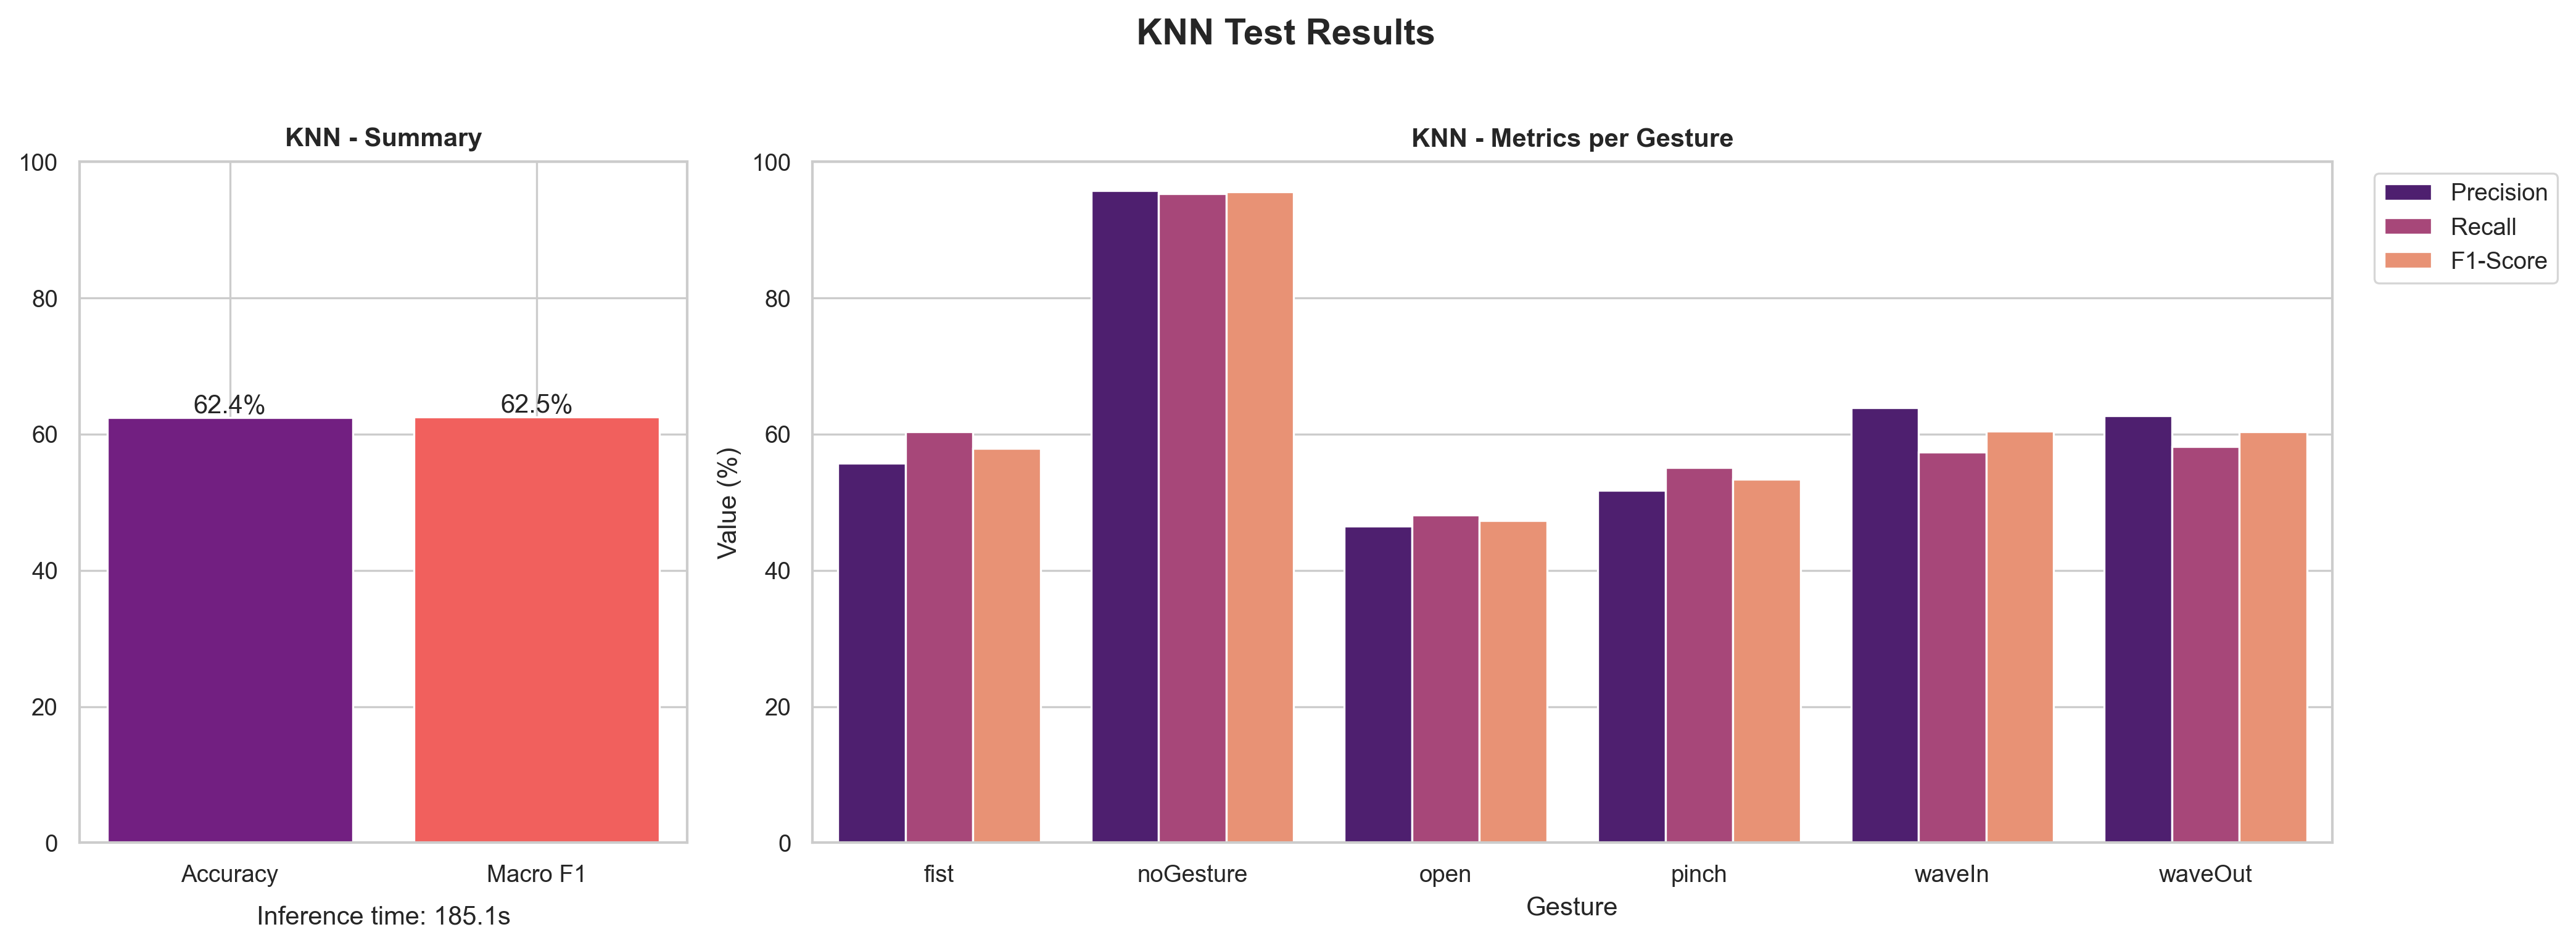

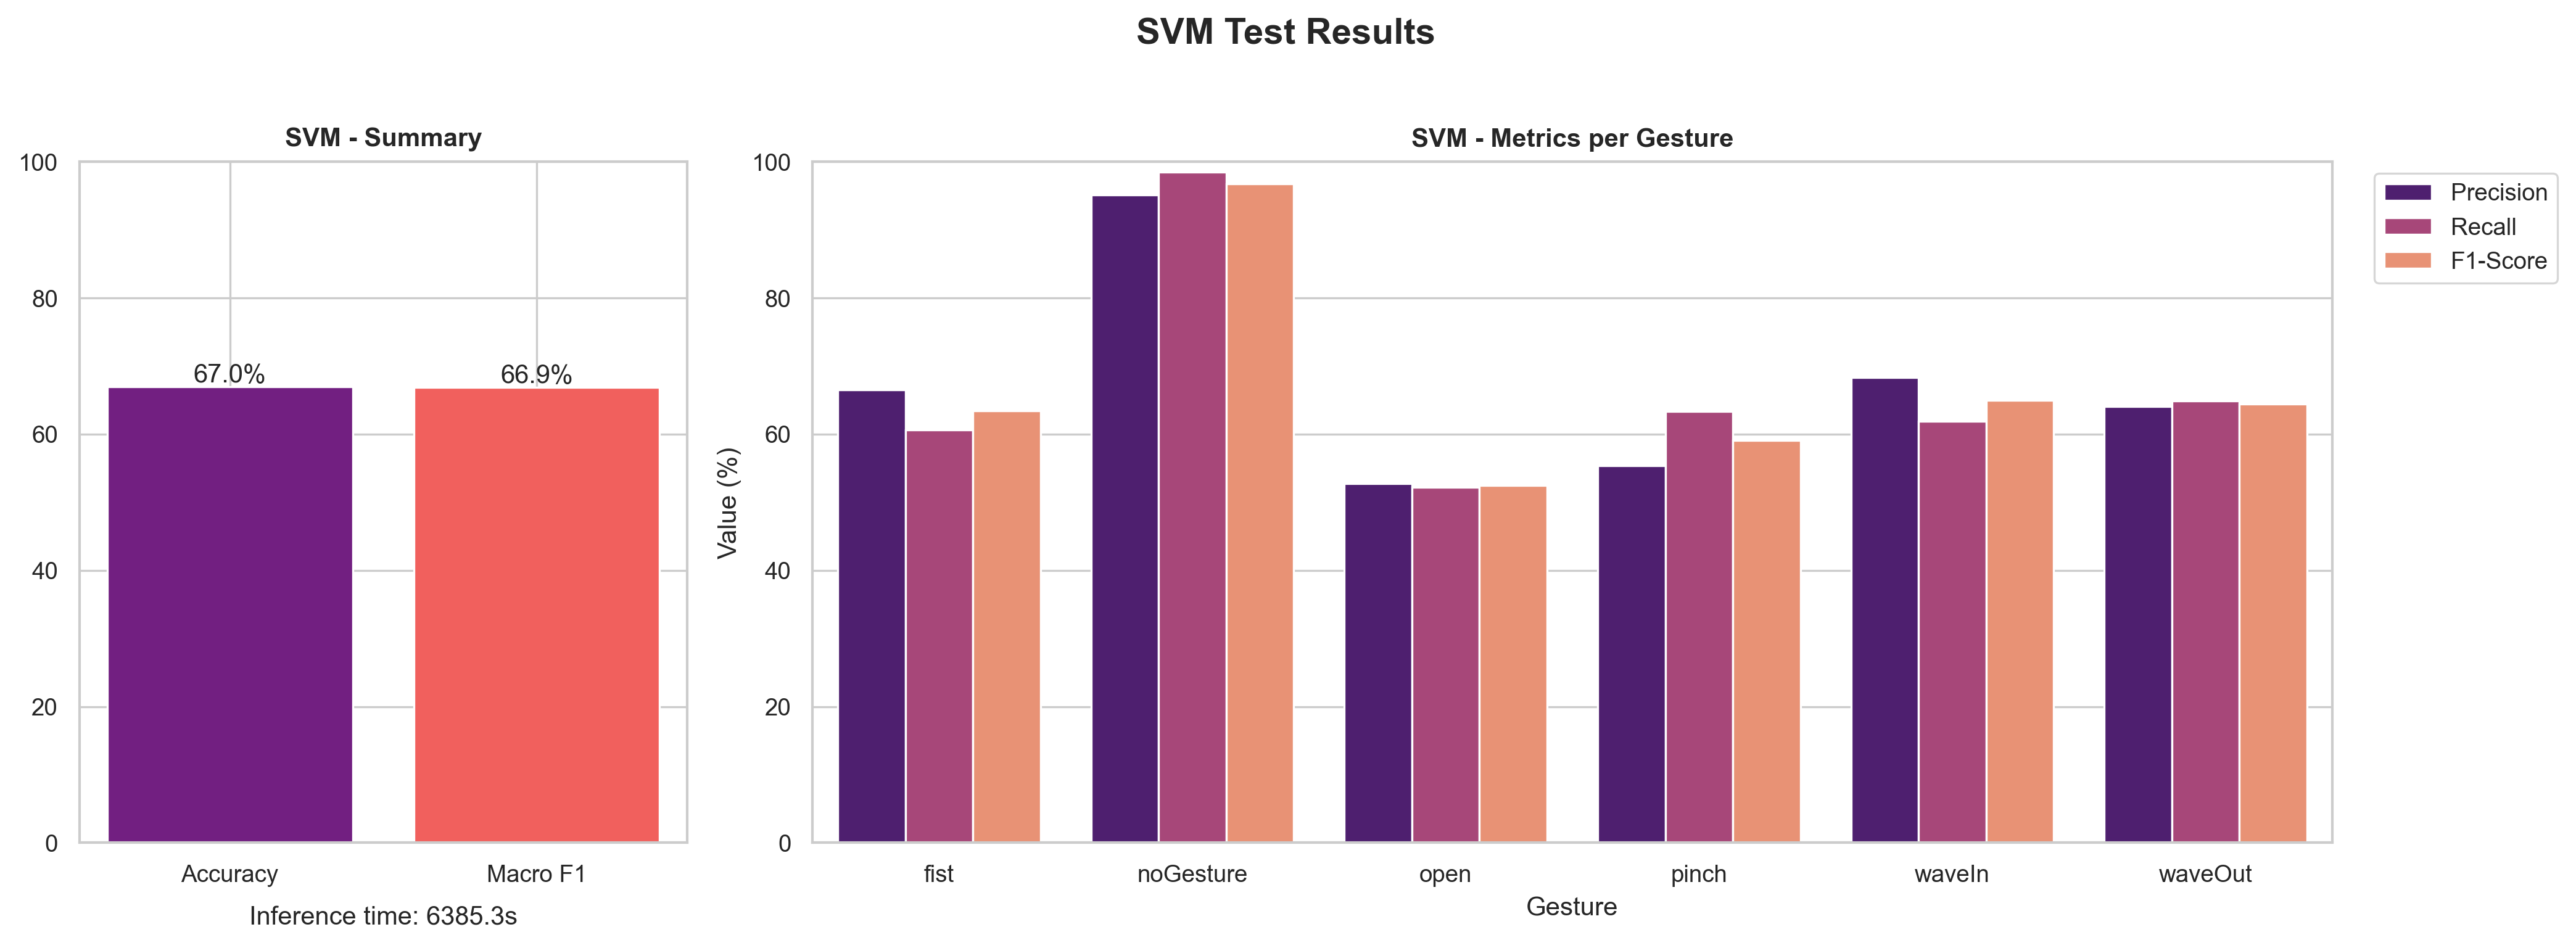

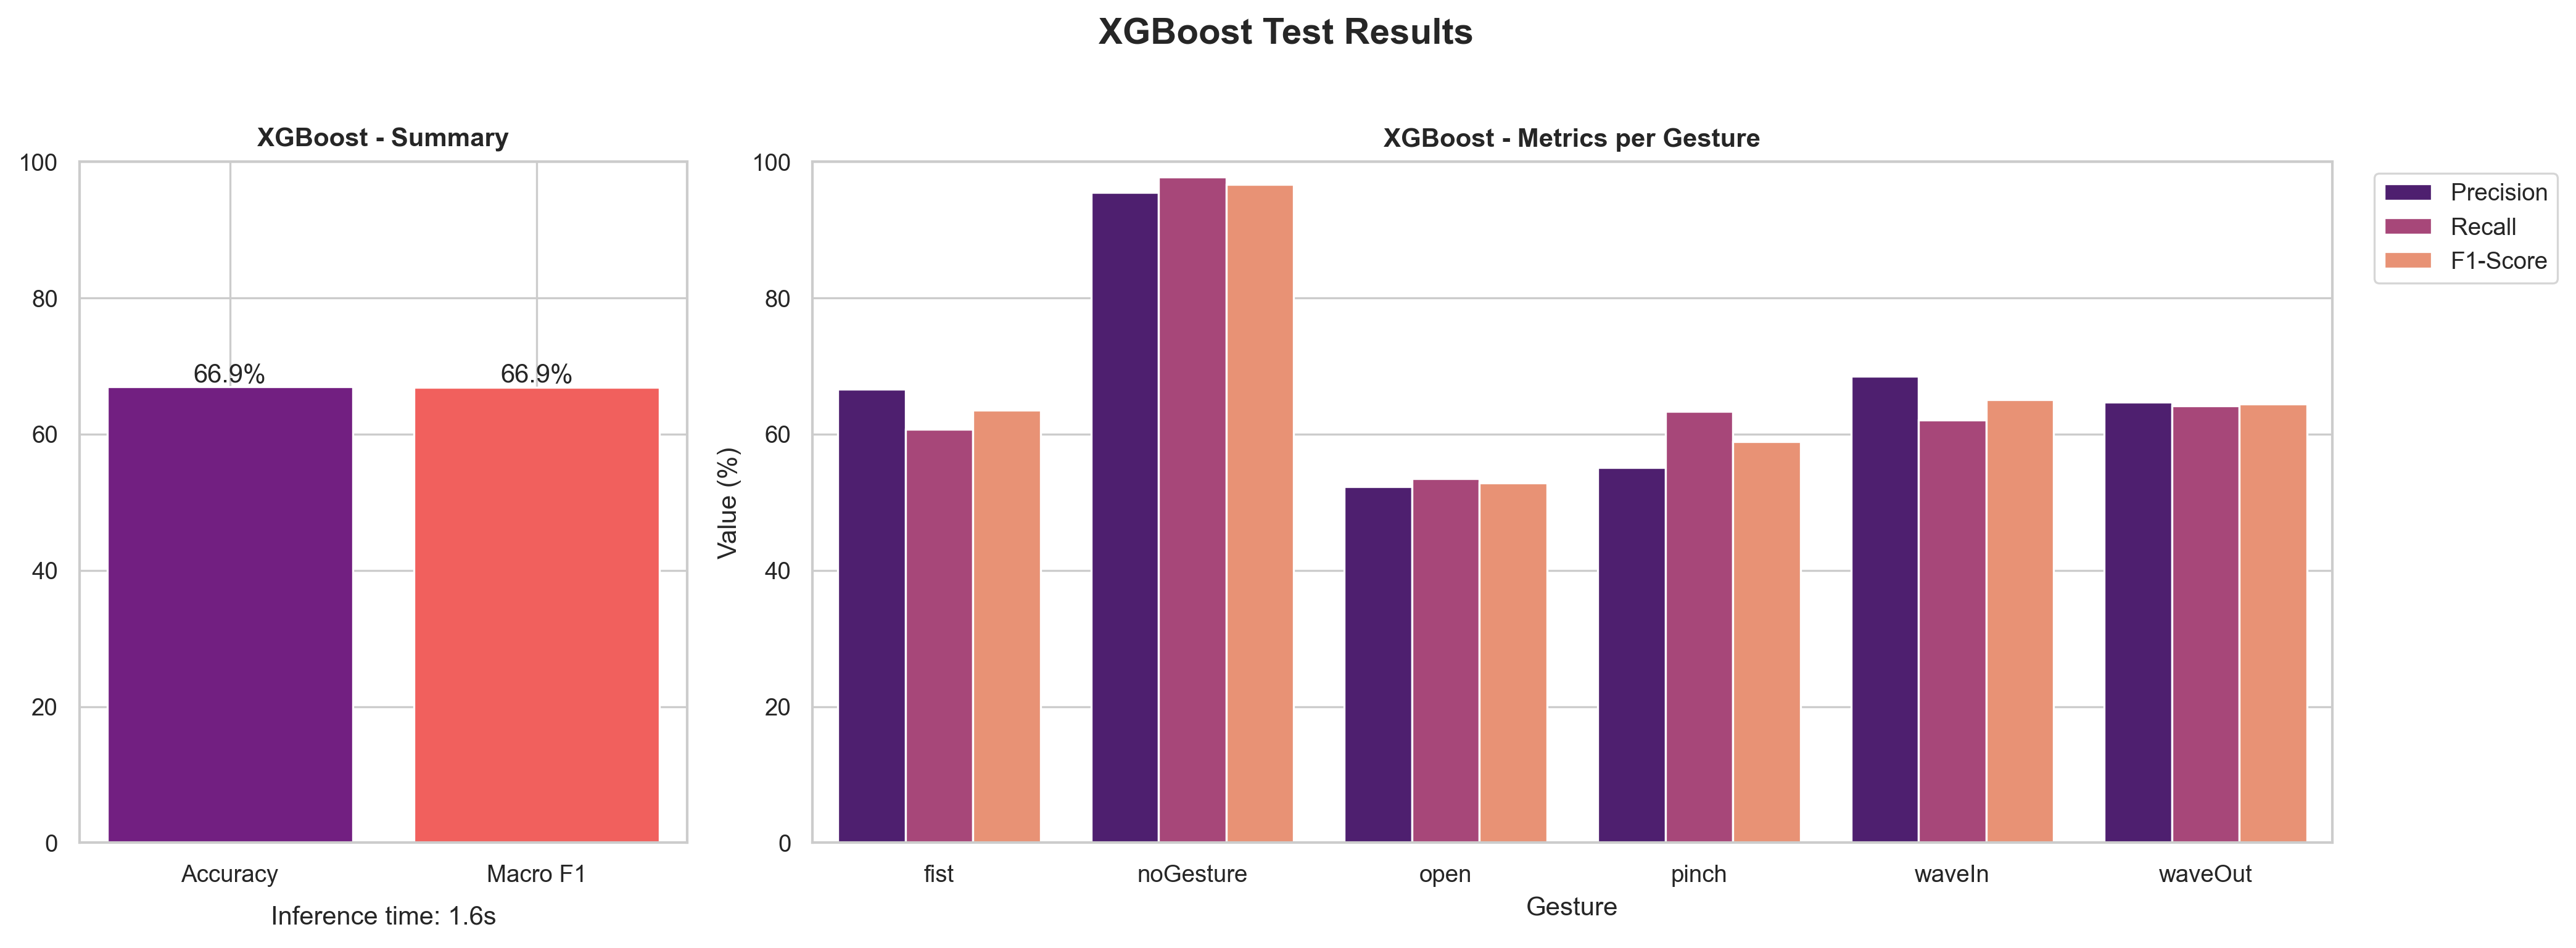

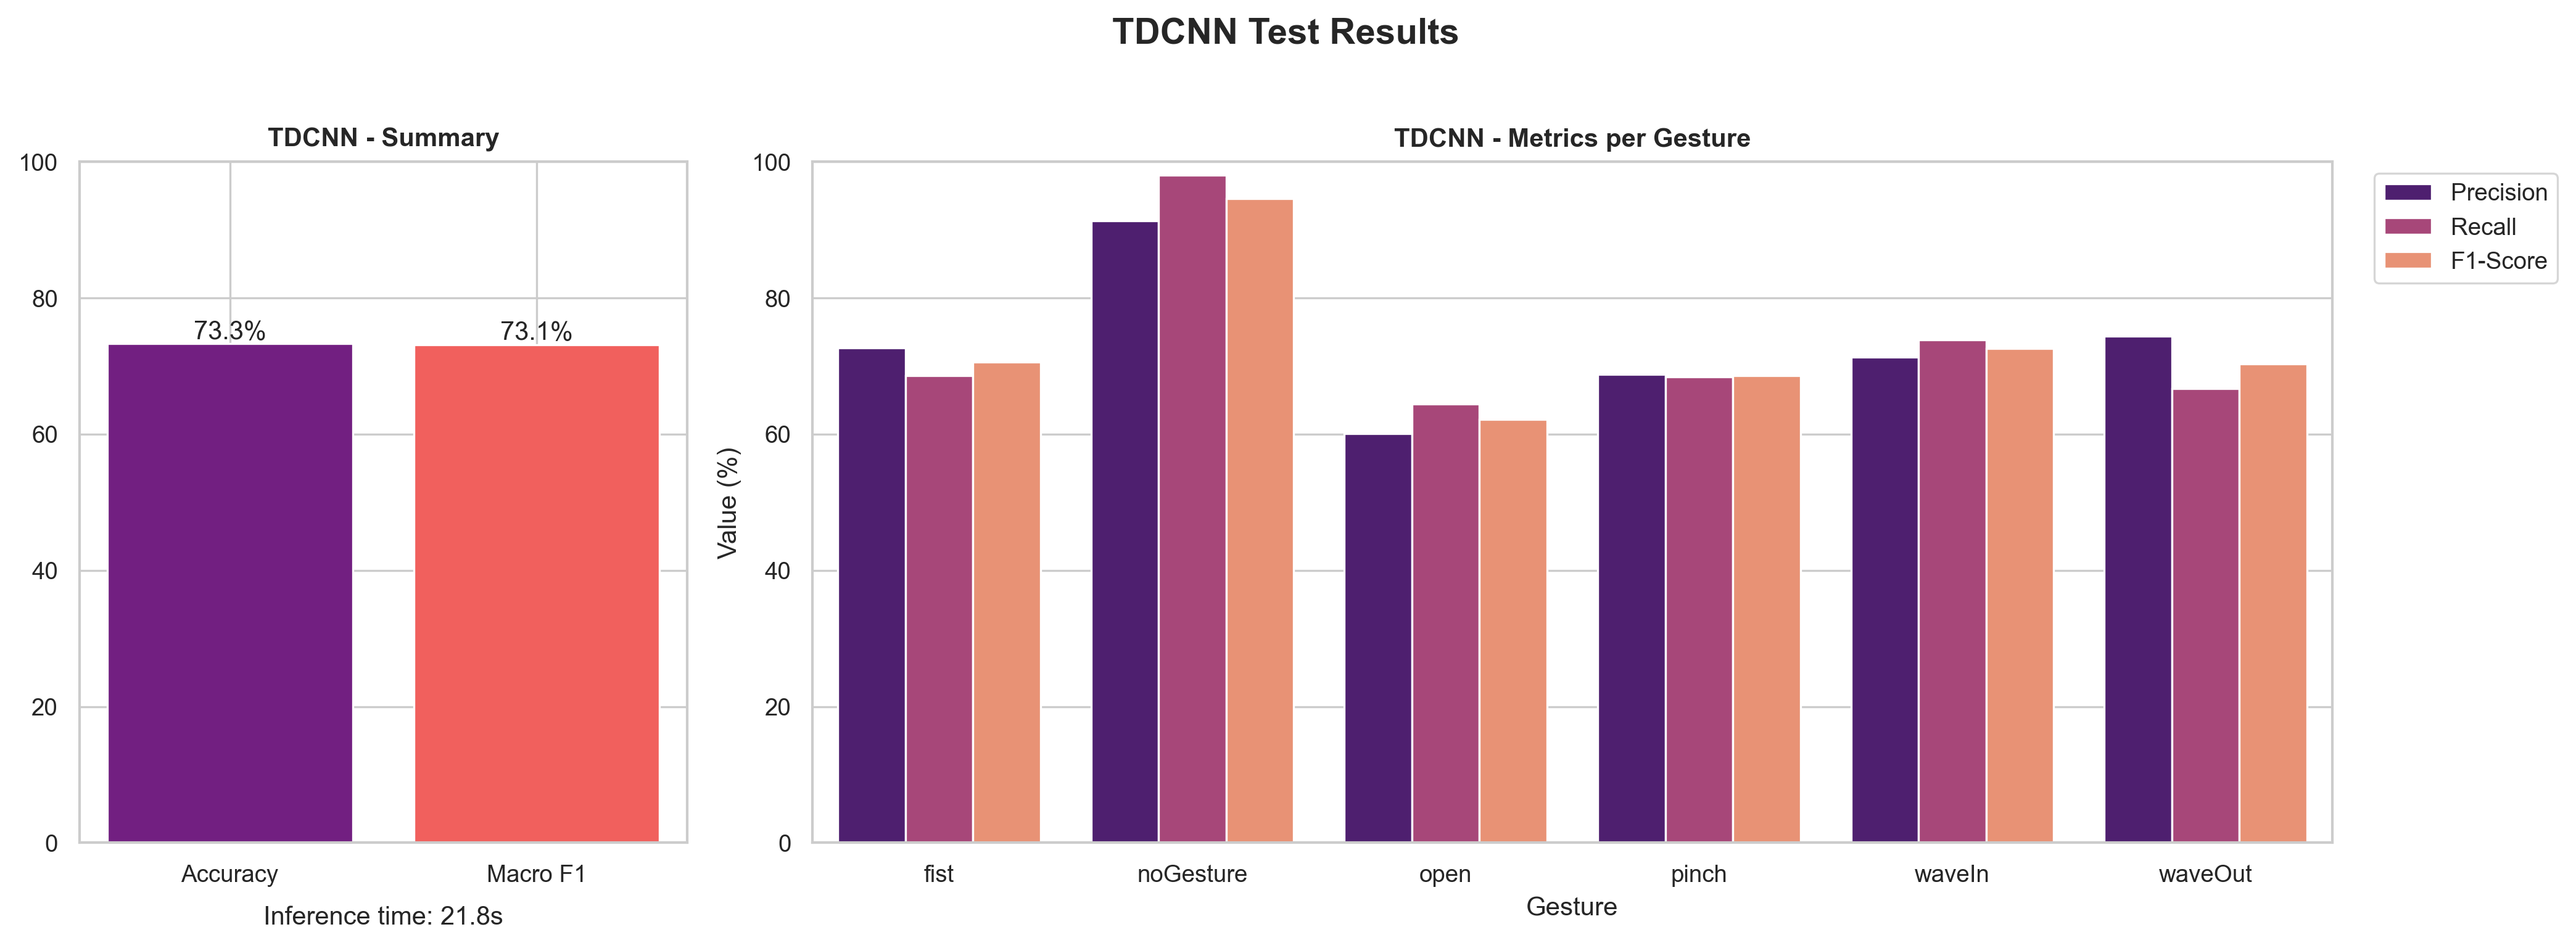

In [2]:
# Load pre-generated images from scripts/visualize_18f_results.py
from IPython.display import Image, display
from pathlib import Path

PROJECT_ROOT = Path("..")
RESULTS_DIR = PROJECT_ROOT / "models" / "18f"

# Images saved by: python scripts/visualize_18f_results.py
IMAGES = {
    "ENN+KNN": RESULTS_DIR / "knn_results.png",
    "GPU RFF-SVM": RESULTS_DIR / "svm_results.png",
    "XGBoost": RESULTS_DIR / "xgboost_results.png",
    "TDCNN": RESULTS_DIR / "tdcnn_results.png",
}

for name, p in IMAGES.items():
    if p.exists():
        display(Image(filename=str(p), width=700))
    else:
        print(f"[Image not found] {name}: {p}")

## 9. Inter-Classifier Performance Evaluation

Global accuracy and macro F1 comparison across all four models.

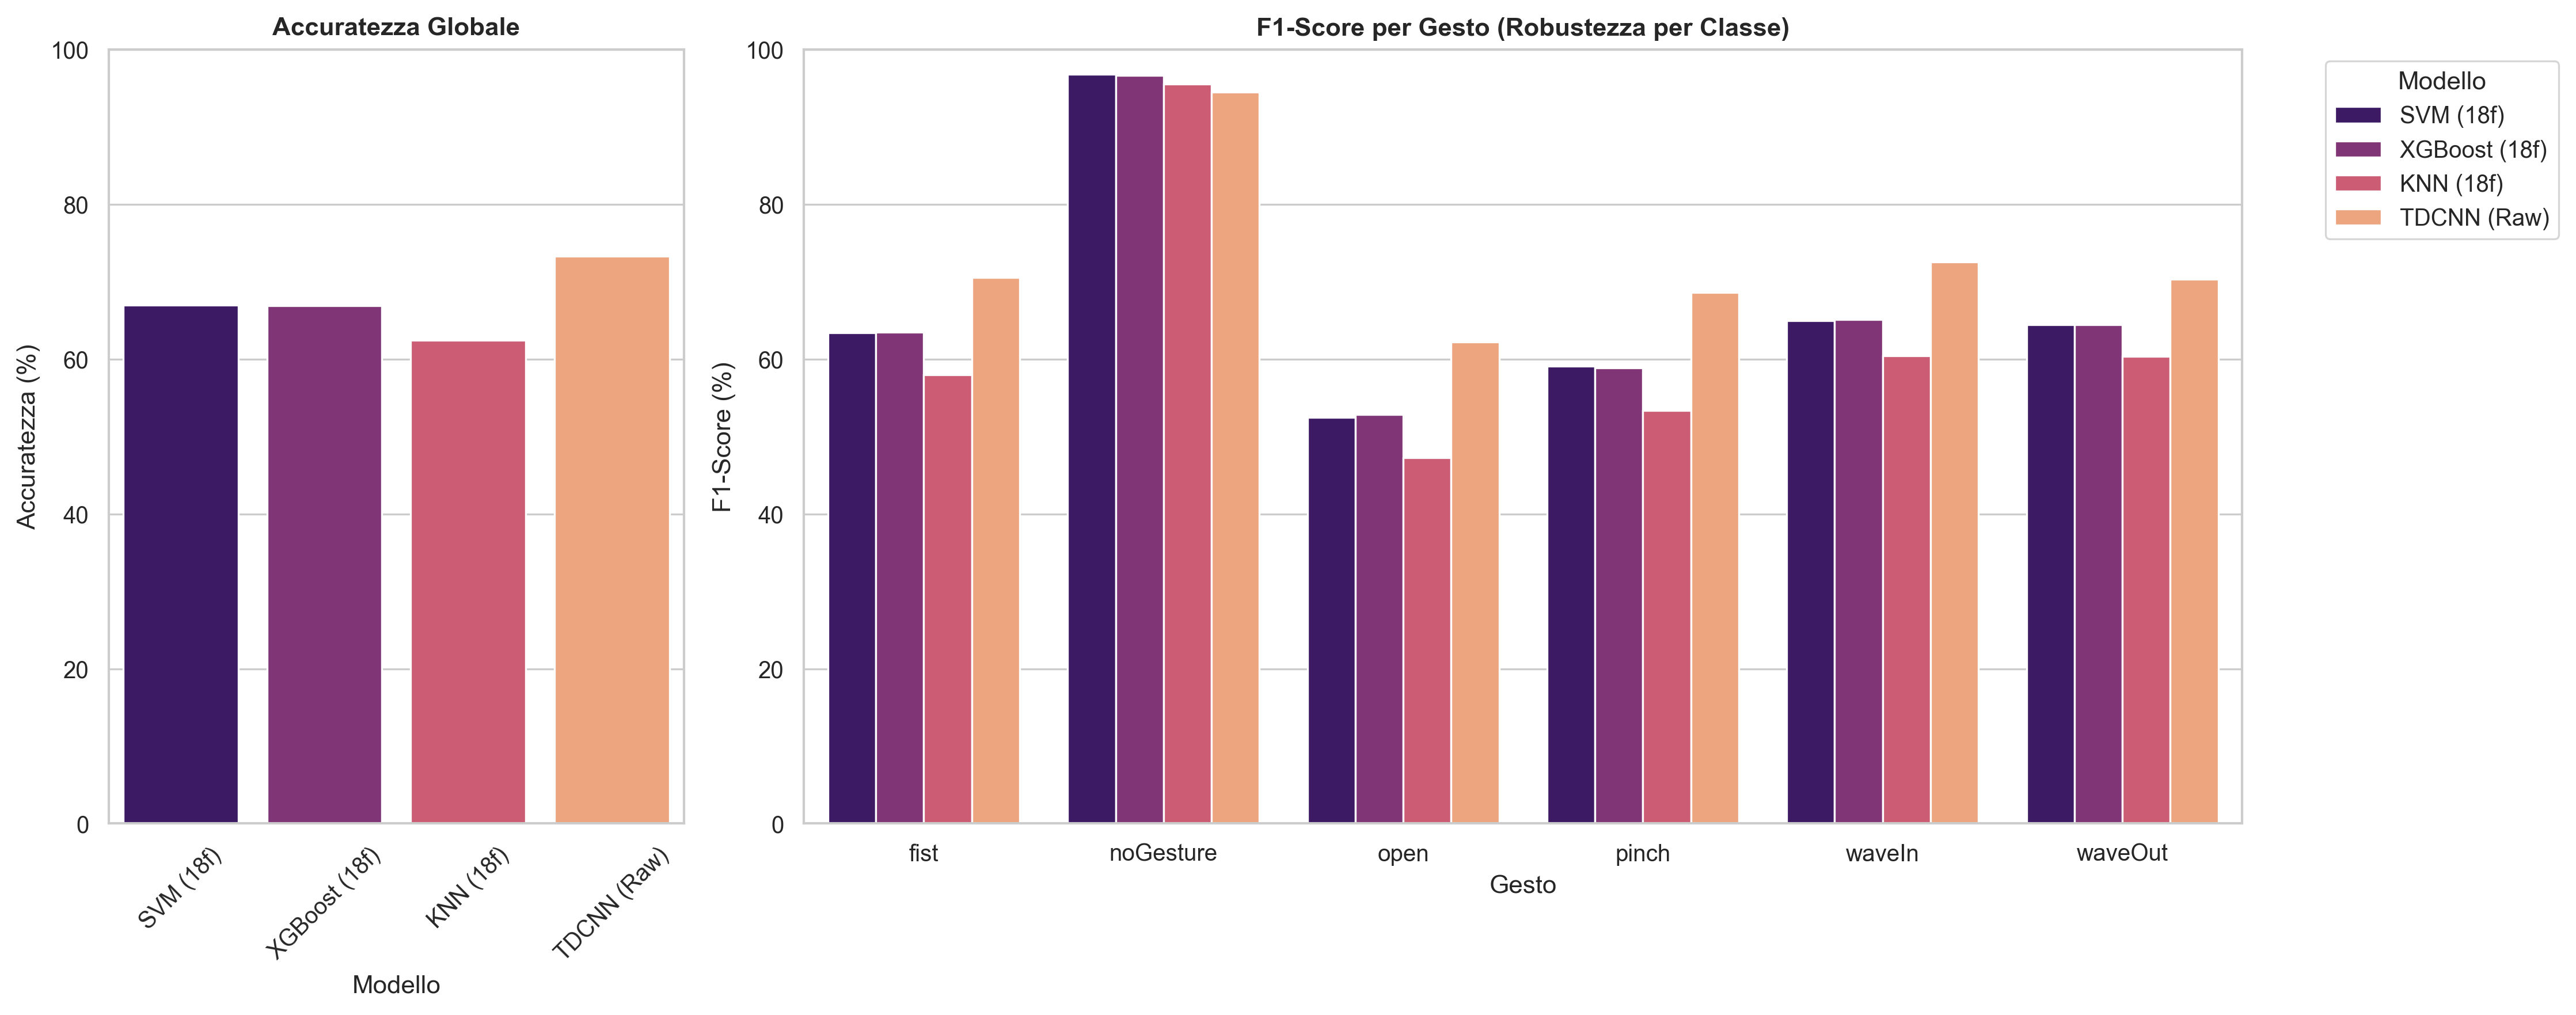

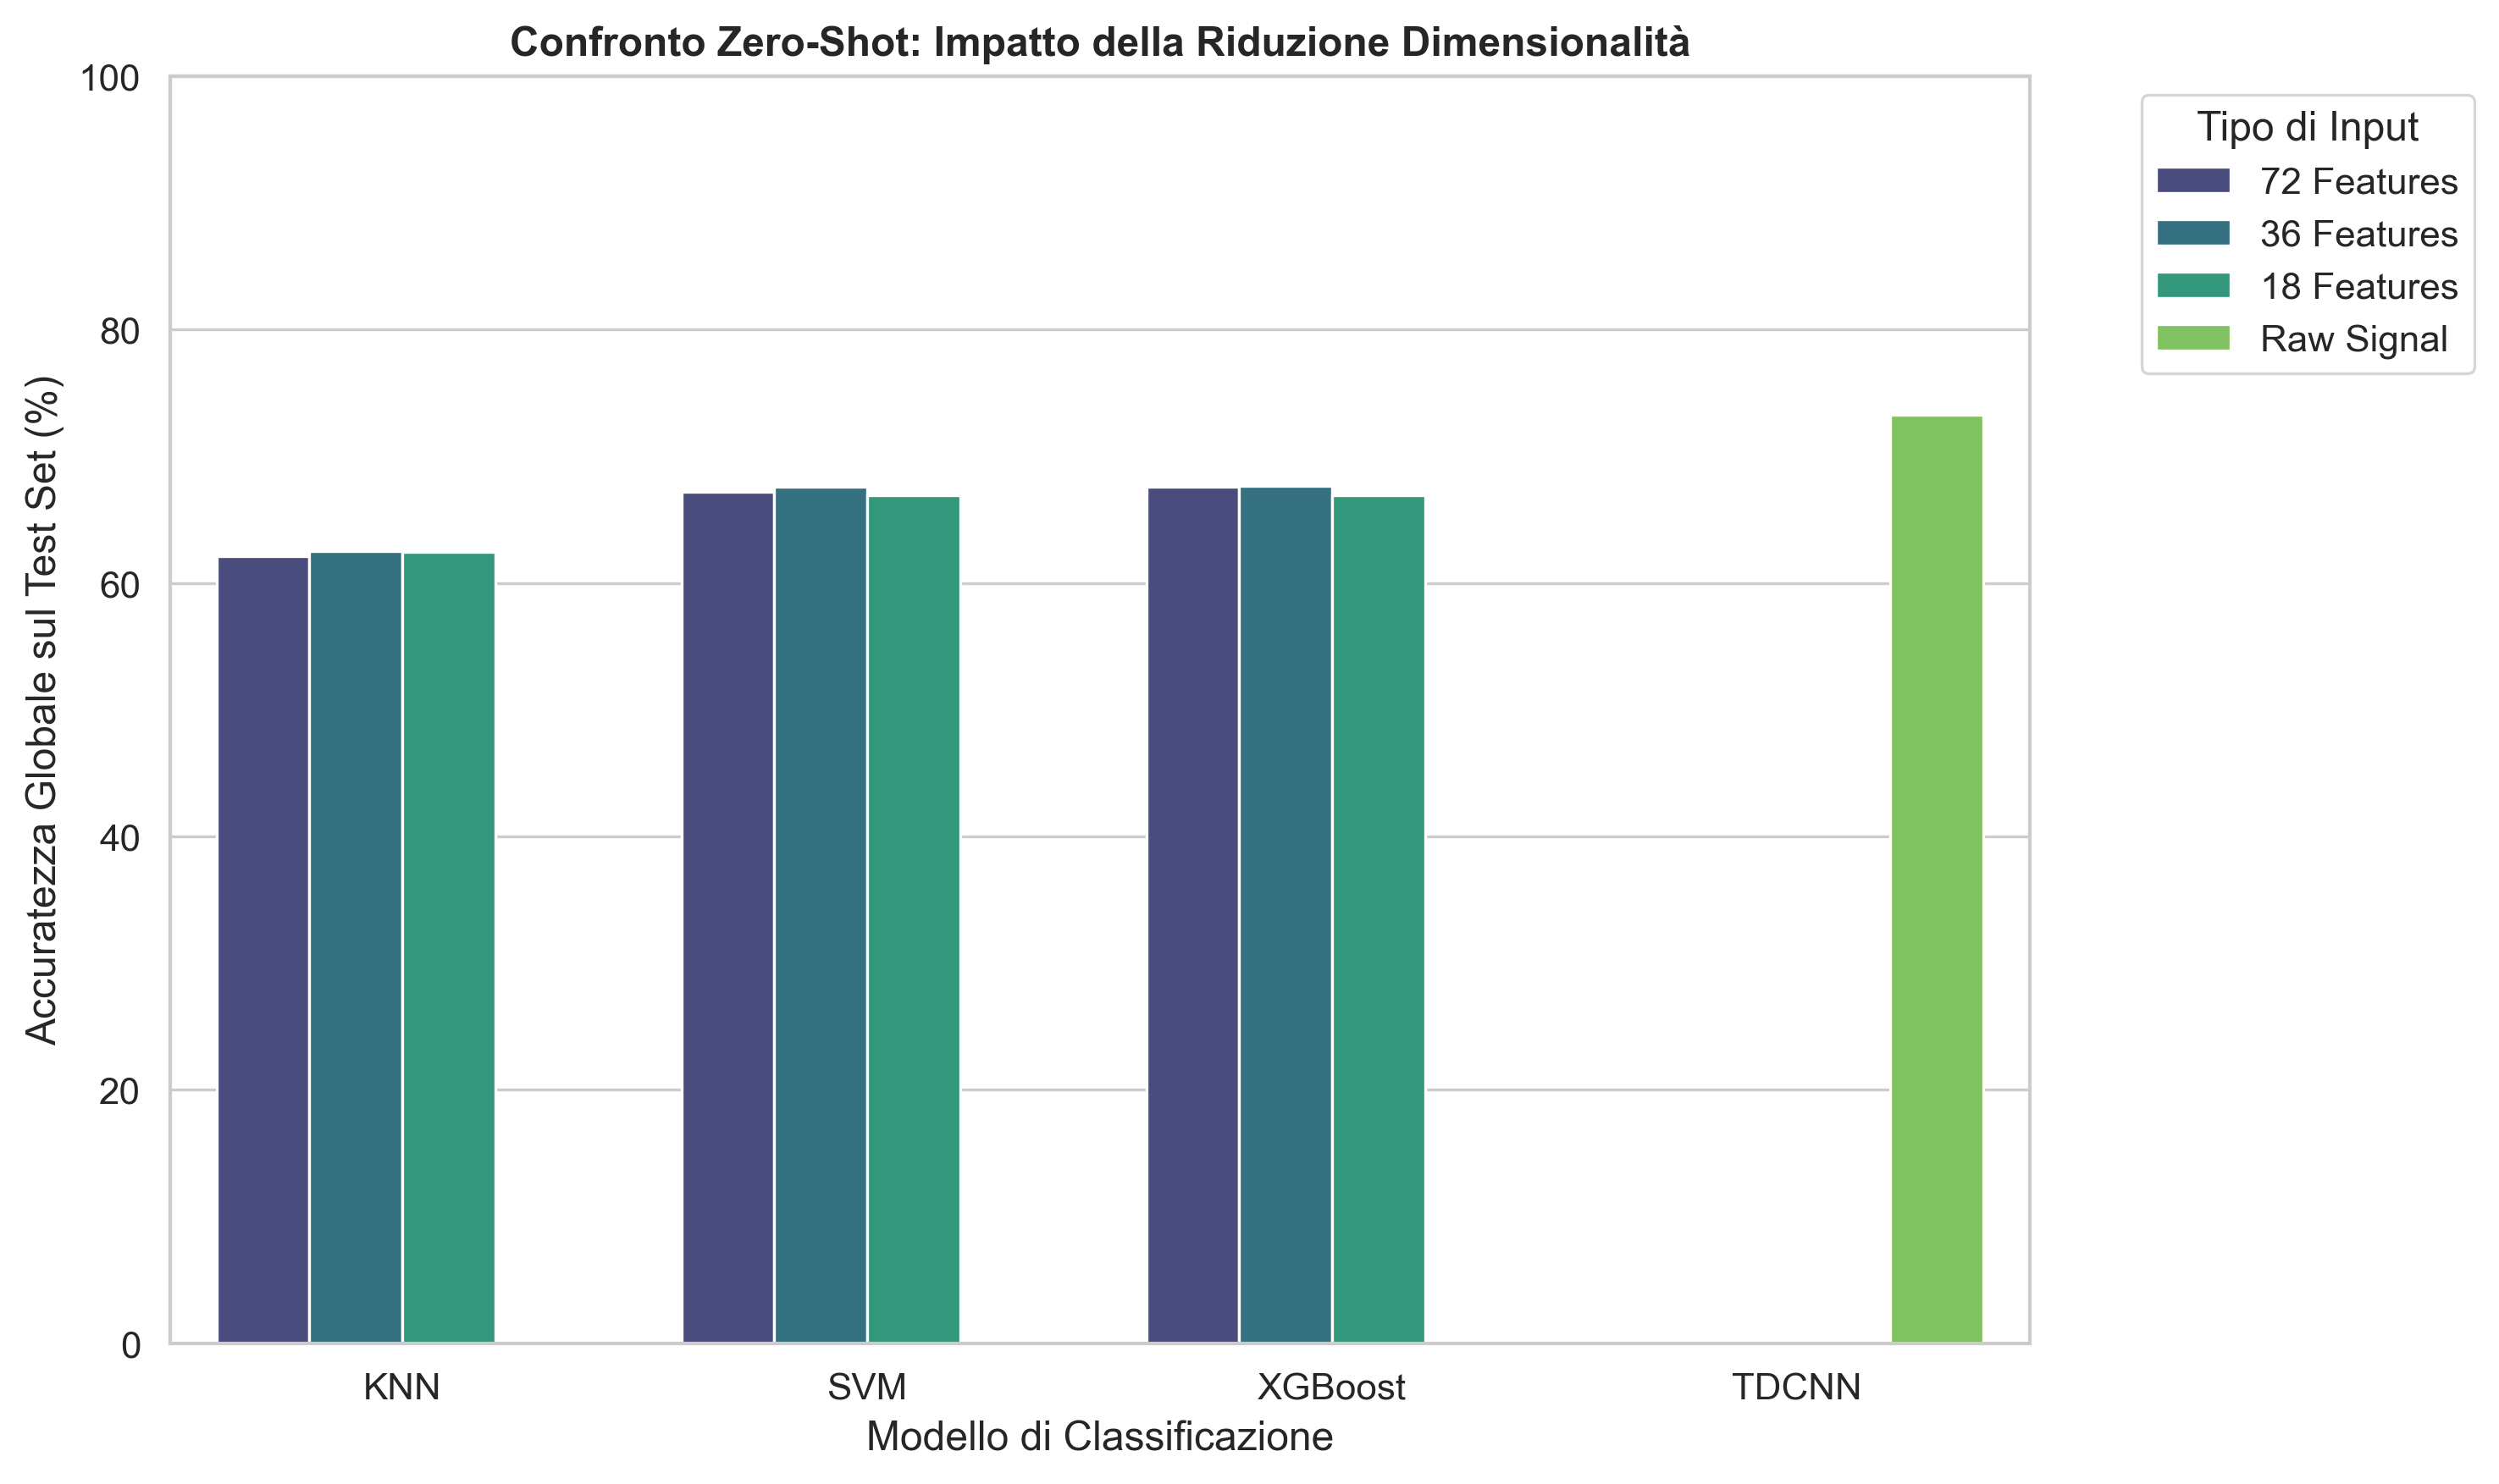

In [3]:
# Load pre-generated images from scripts/comparison_models.py and comparison_feature_selection.py
from IPython.display import Image, display
from pathlib import Path

PROJECT_ROOT = Path("..")
MODELS_DIR = PROJECT_ROOT / "models"

# Inter-classifier comparison (scripts/comparison_models.py)
p1 = MODELS_DIR / "model_comparison_gestures.png"
if p1.exists():
    display(Image(filename=str(p1), width=800))
else:
    print(f"[Image not found] {p1}")

# Zero-shot feature dimensionality comparison (scripts/comparison_feature_selection.py)
p2 = MODELS_DIR / "zero_shot_comparison_plot.png"
if p2.exists():
    display(Image(filename=str(p2), width=800))
else:
    print(f"[Image not found] {p2}")

## 10. Post-Calibration Results

Per-user calibration using 25 training samples from testing users. Zero-shot vs calibrated accuracy comparison.

### Calibration Dashboard


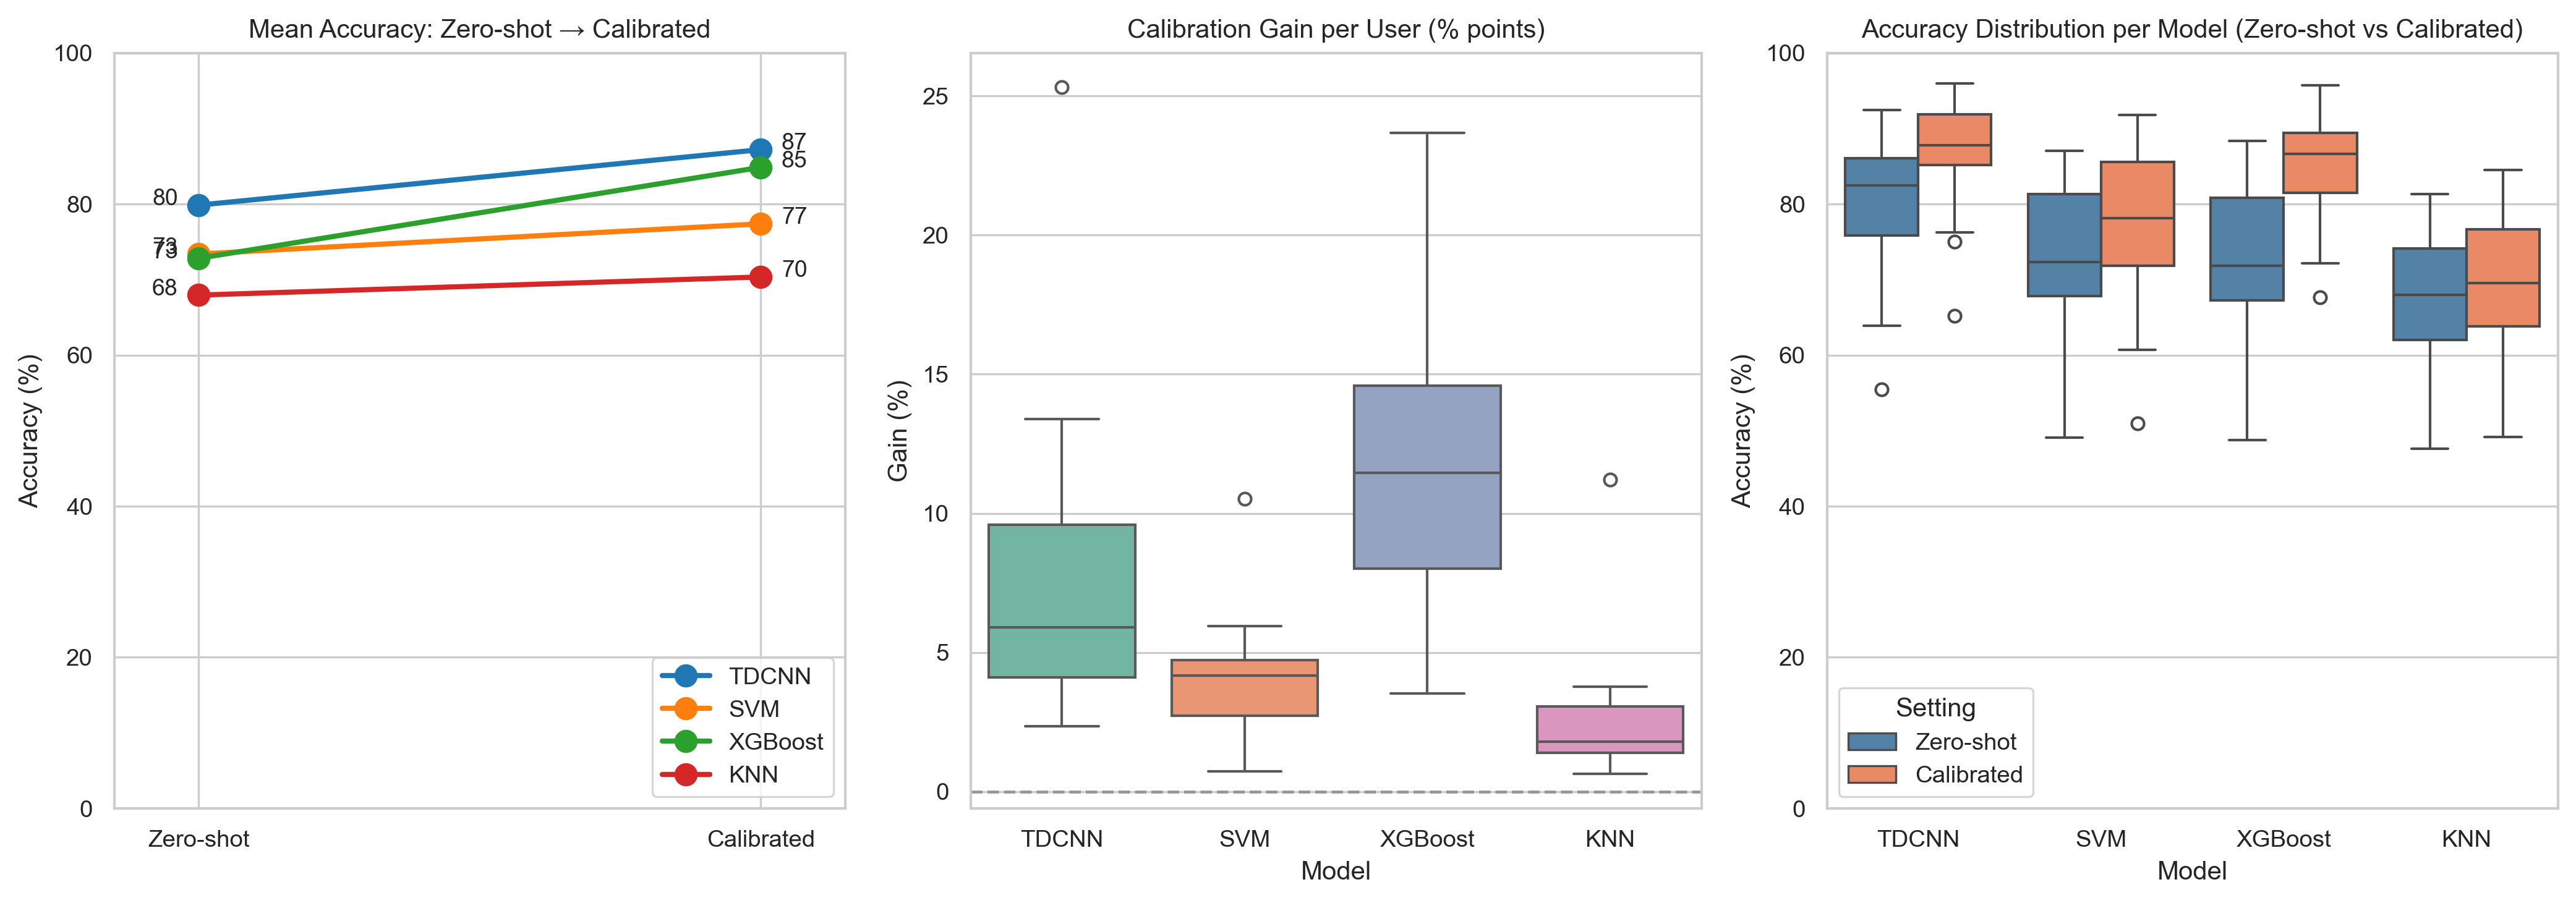

### Calibration Improvement Table


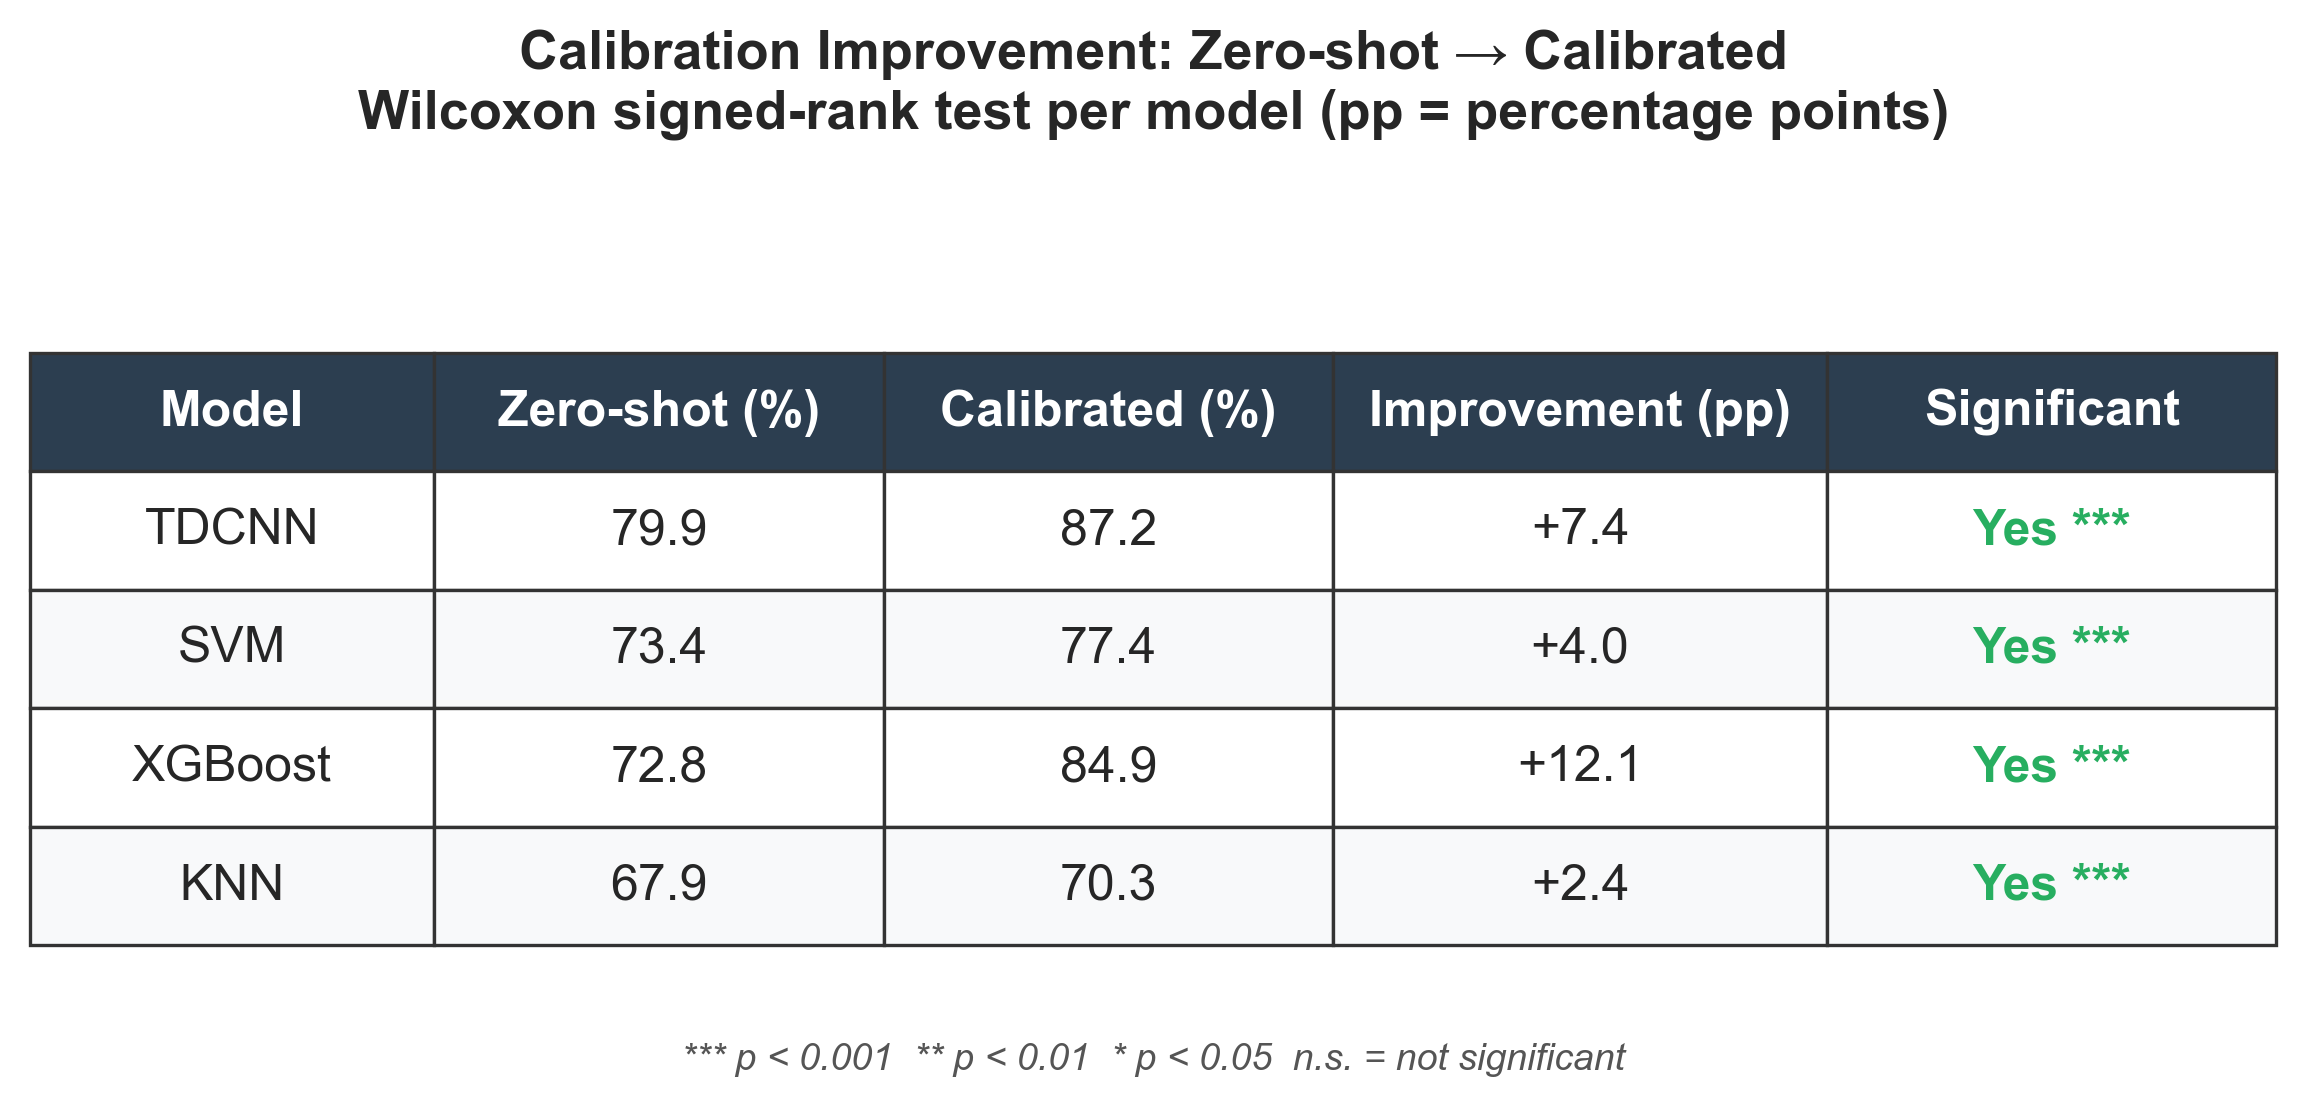

### Statistical Significance


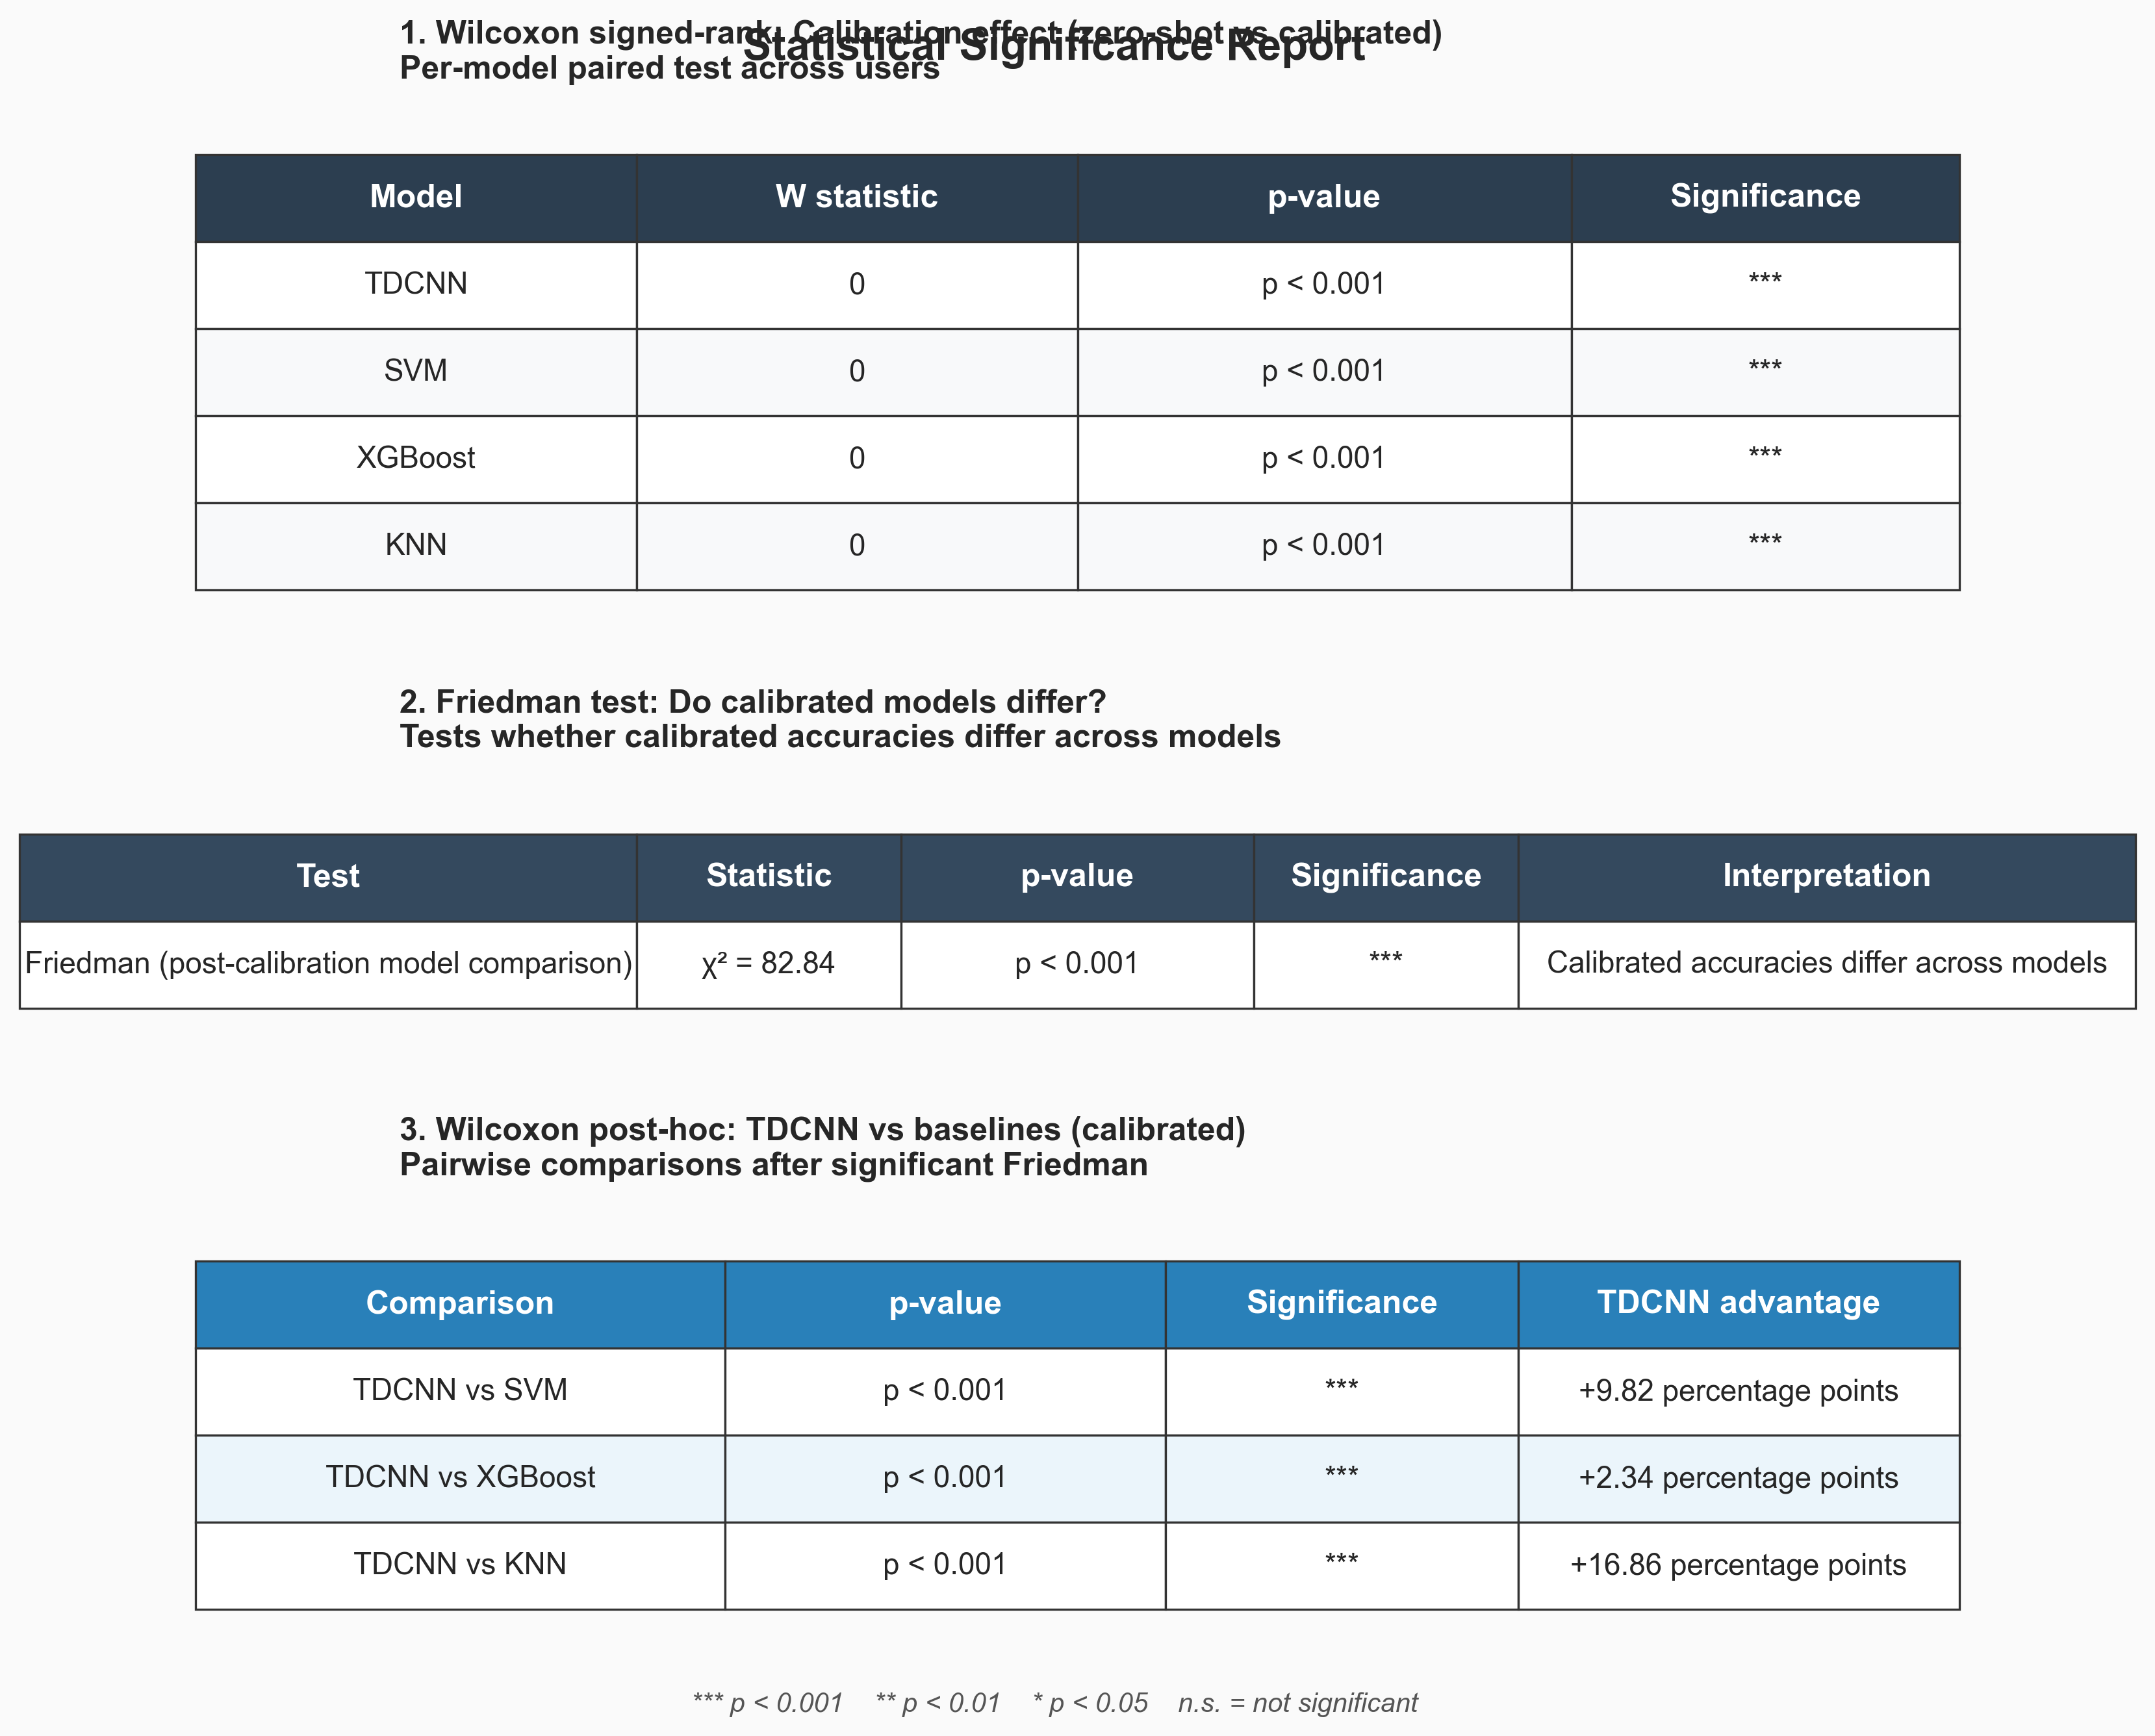

### XGBoost 18f F1 per Gesture


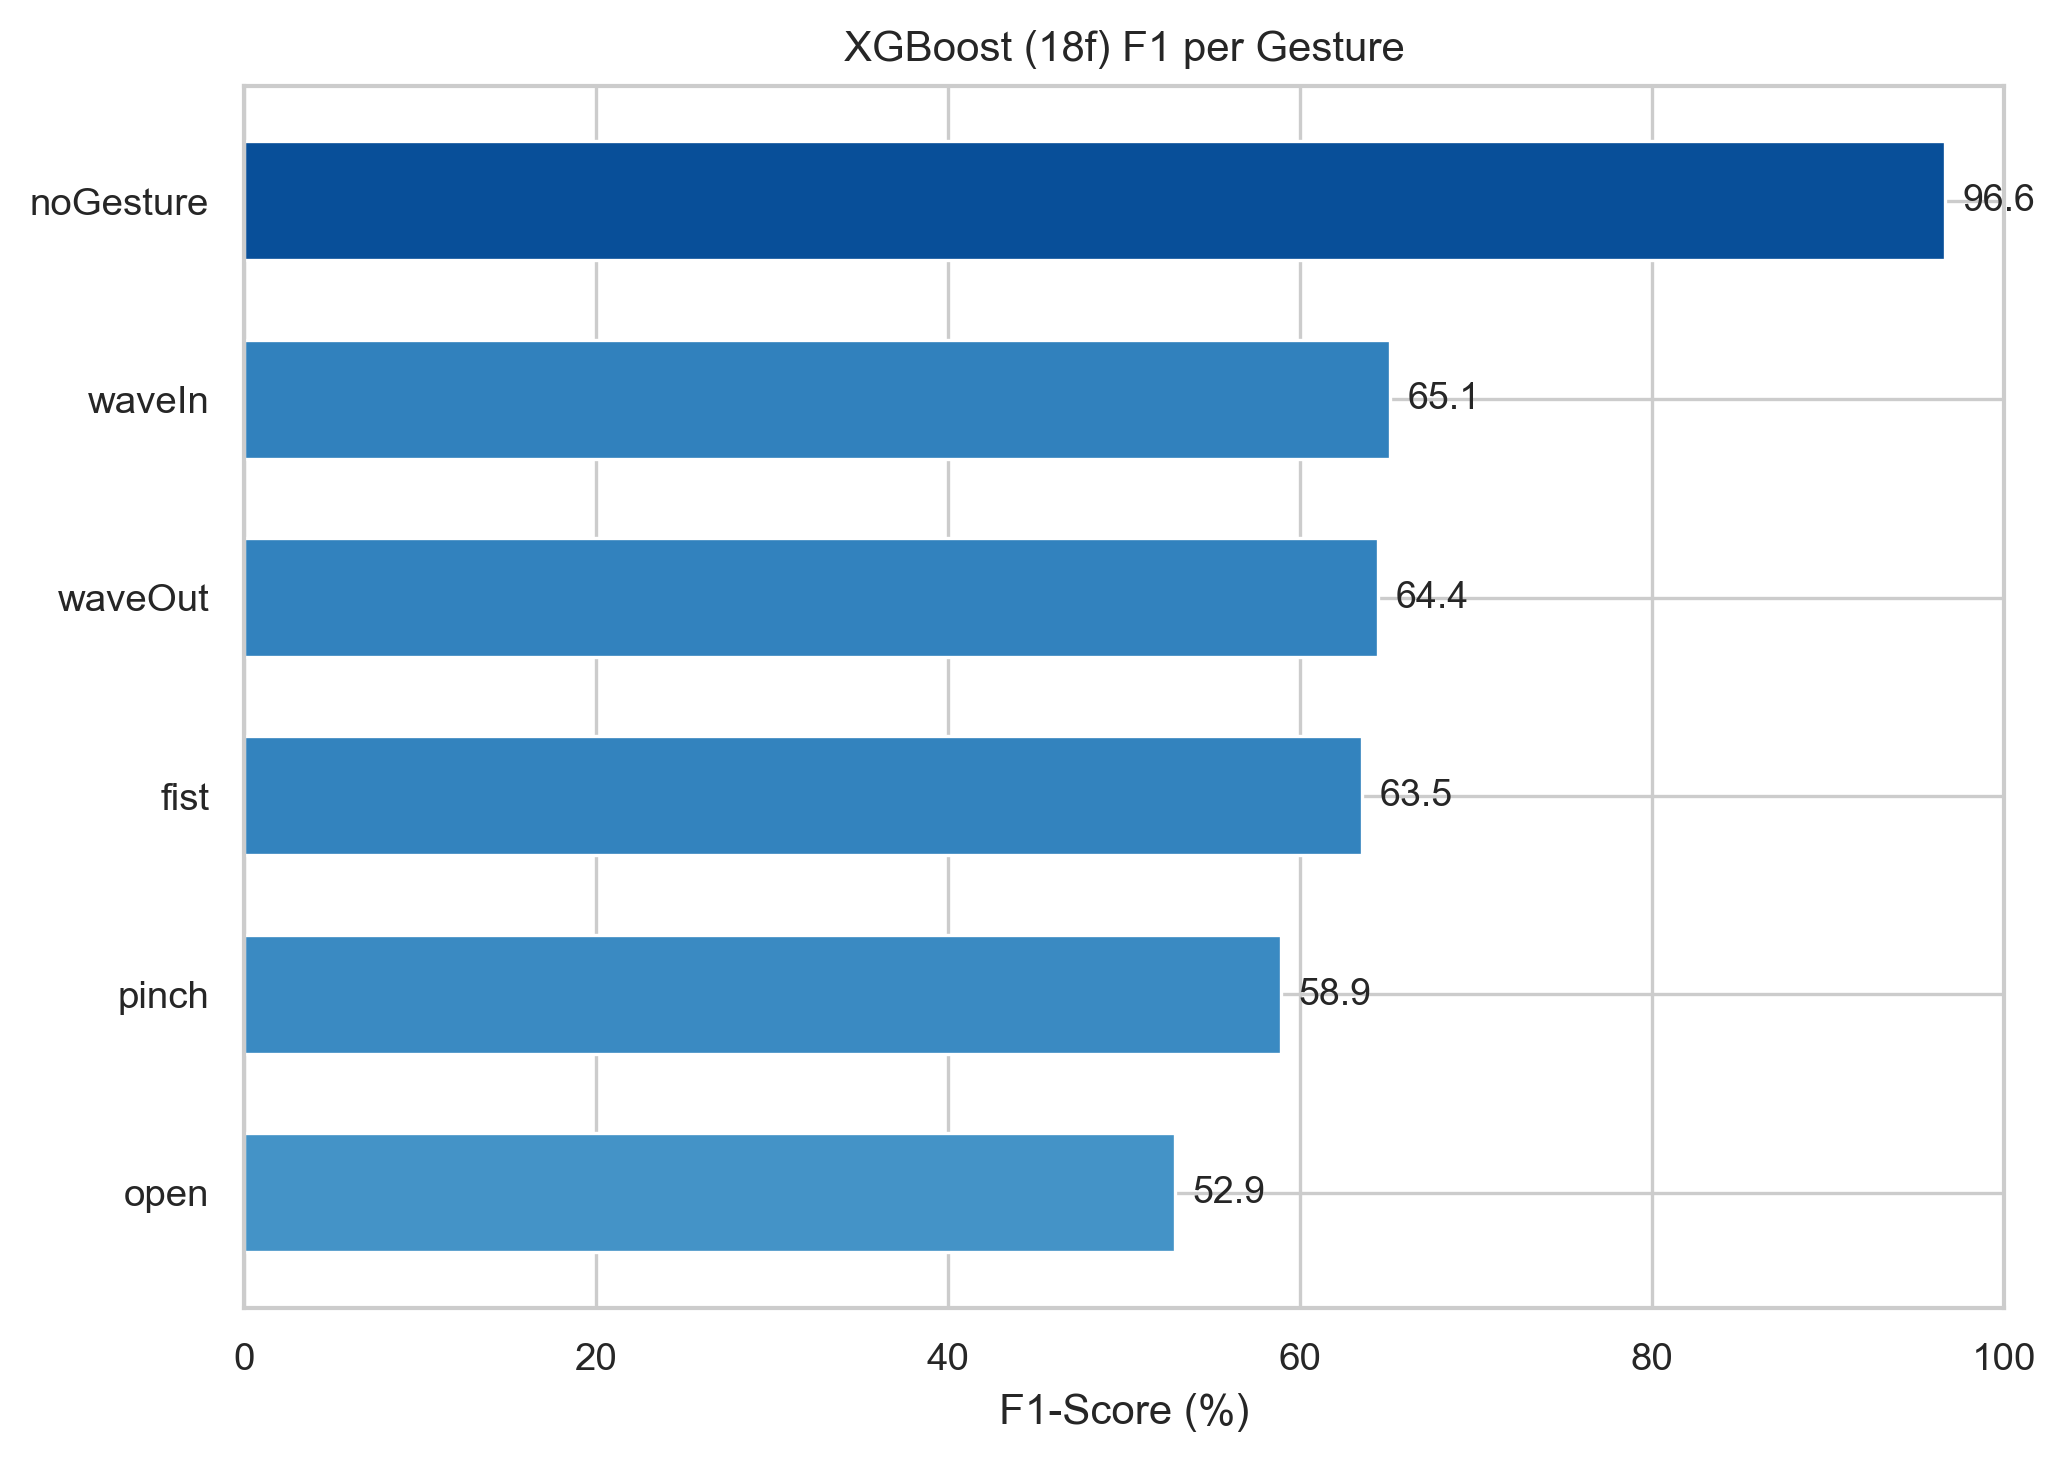

In [4]:
# Load pre-generated images from scripts/visualize_calibration_results.py
from IPython.display import Image, display
from pathlib import Path

PROJECT_ROOT = Path("..")
PLOTS_DIR = PROJECT_ROOT / "preprocessed_output" / "calibration_results" / "plots"

# Images saved by: python scripts/visualize_calibration_results.py
IMAGES = [
    ("Calibration Dashboard", PLOTS_DIR / "calibration_dashboard.png"),
    ("Calibration Improvement Table", PLOTS_DIR / "calibration_improvement_table.png"),
    ("Statistical Significance", PLOTS_DIR / "statistical_significance_table.png"),
    ("XGBoost 18f F1 per Gesture", PLOTS_DIR / "xgboost18_f1_per_gesture.png"),
]

for title, p in IMAGES:
    if p.exists():
        print(f"### {title}")
        display(Image(filename=str(p), width=700))
    else:
        print(f"[Image not found] {title}: {p}")

## 11. Confusion Matrix (TDCNN)

Image generated by `scripts/eval_tdcnn.py` (saved to project root as `confusion_matrix.png`).

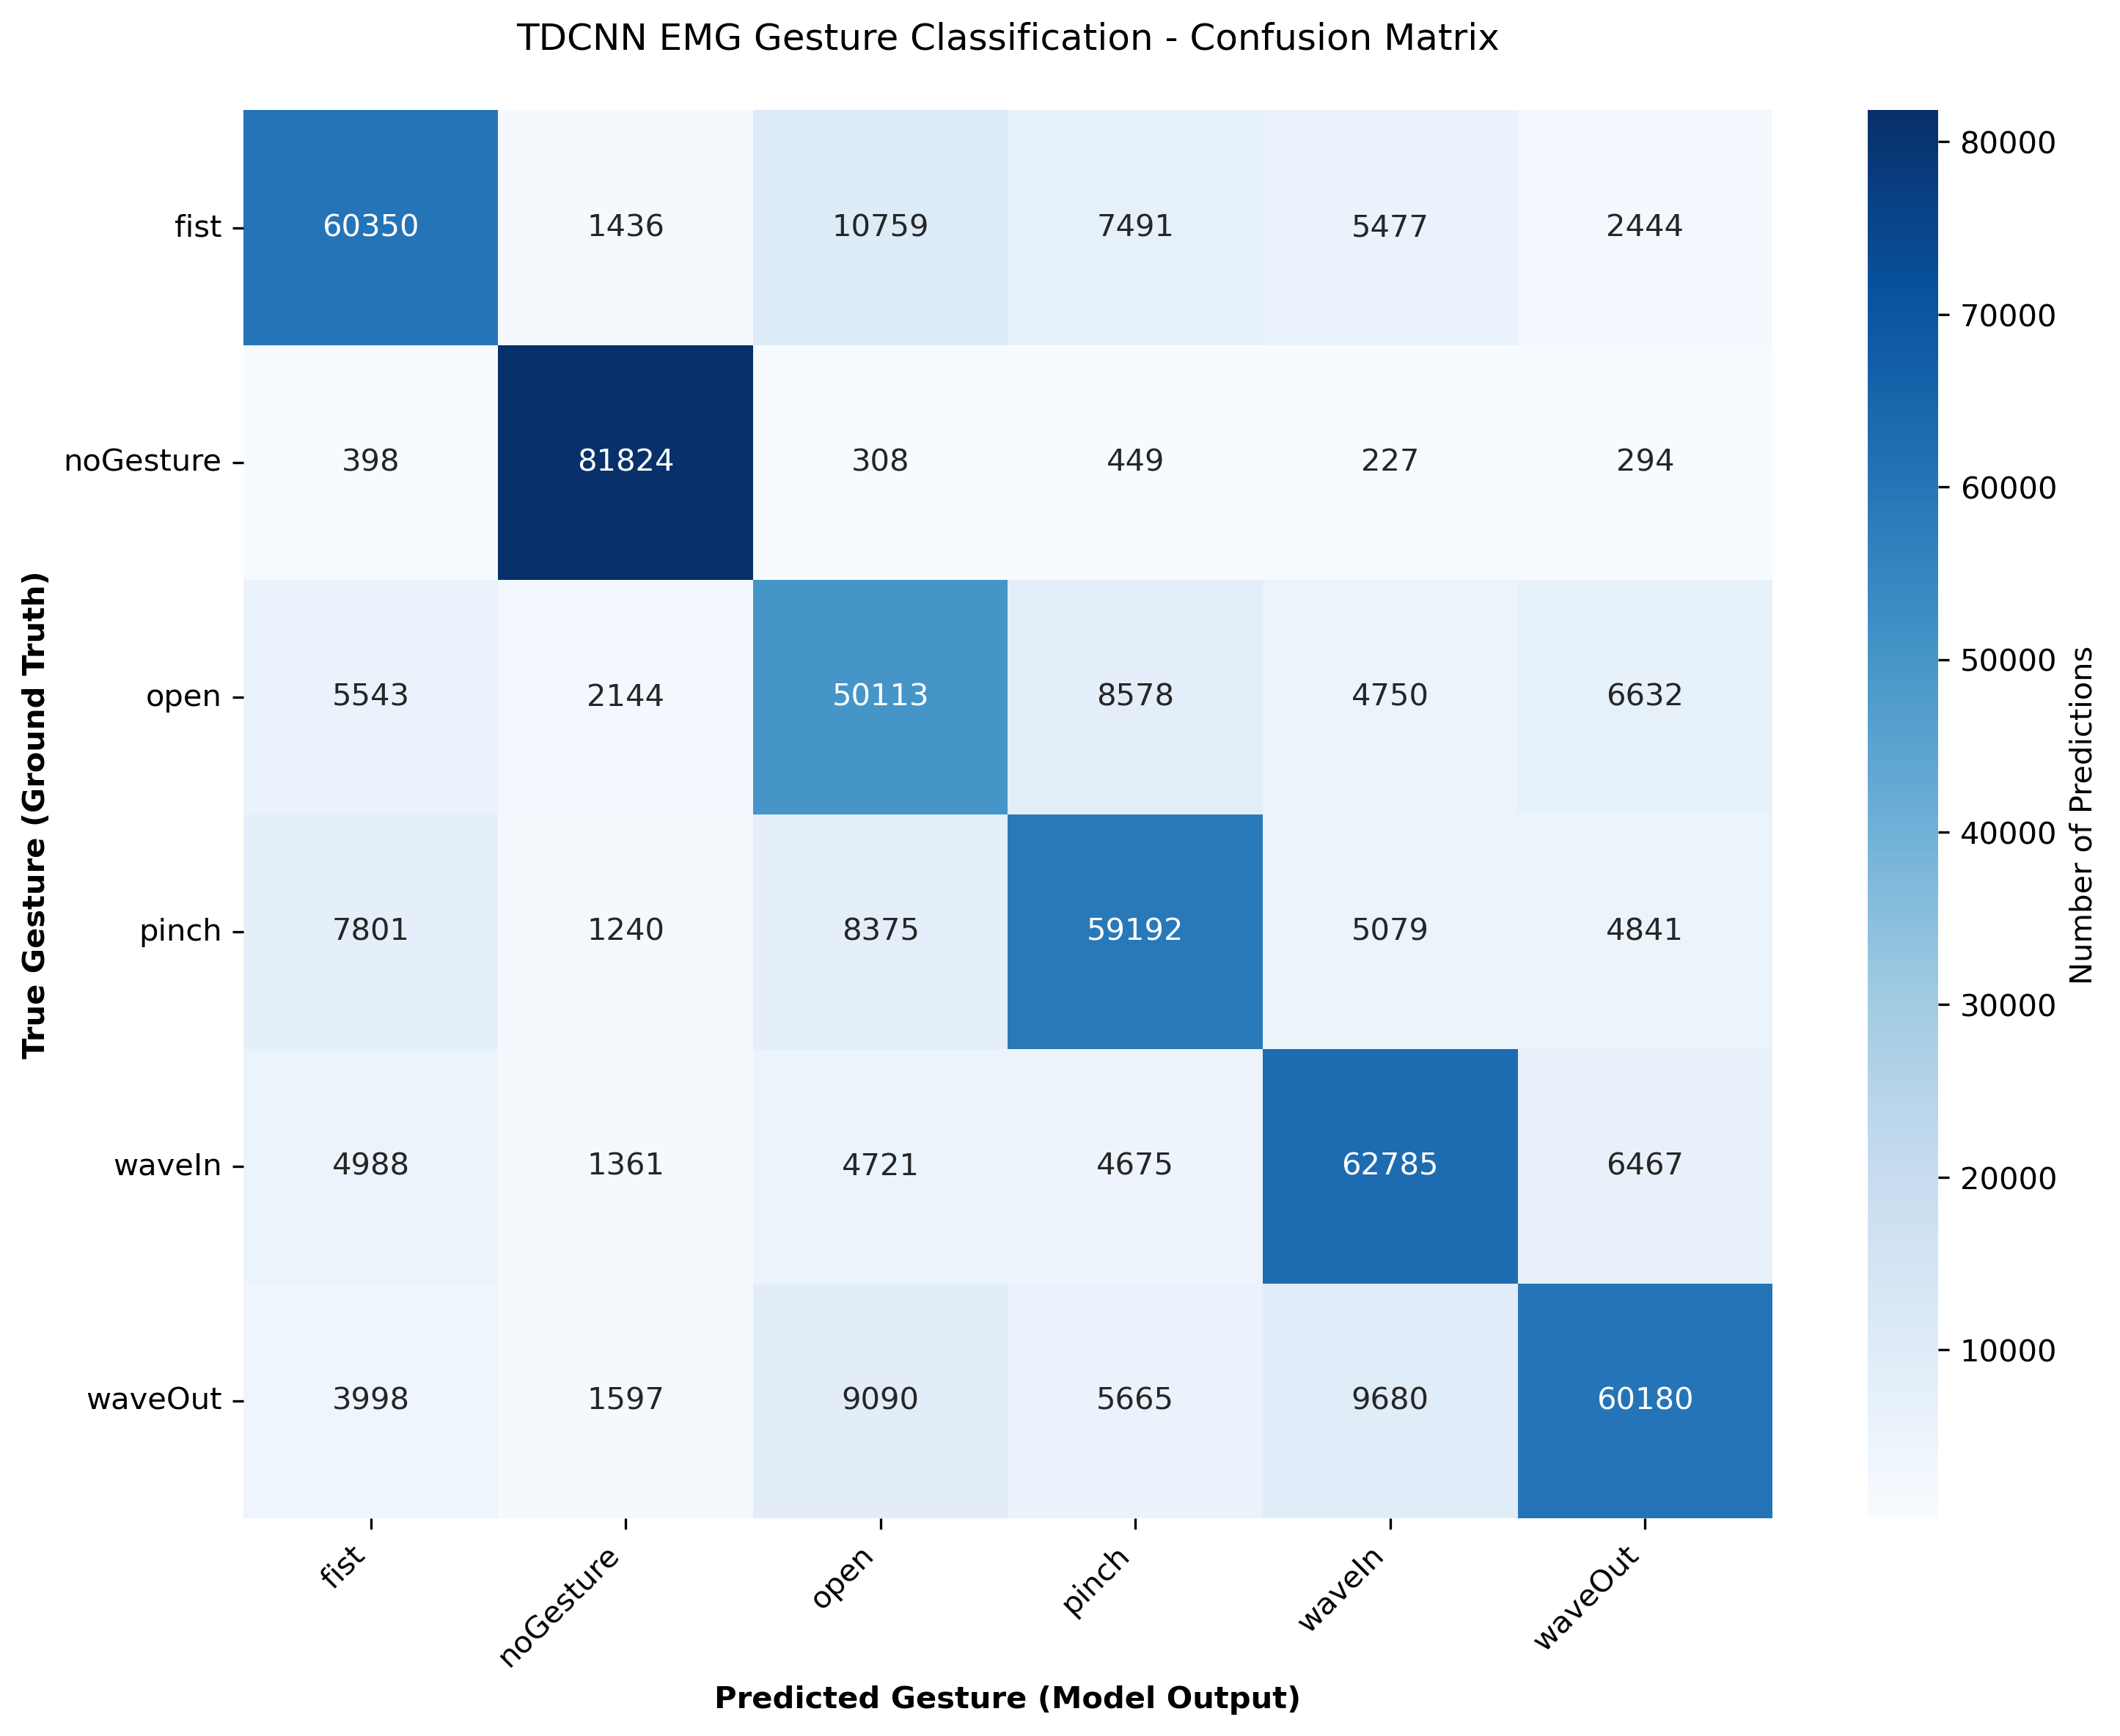

In [5]:
# Load pre-generated confusion matrix from scripts/eval_tdcnn.py (saved to project root)
from IPython.display import Image, display
from pathlib import Path

# eval_tdcnn.py saves confusion_matrix.png in the directory from which it is run (project root)
p = Path("..") / "confusion_matrix.png"
if p.exists():
    display(Image(filename=str(p), width=650))
else:
    print(f"[Image not found] {p}\nRun: python scripts/eval_tdcnn.py")

## 12. References

- **Dataset (EMG-EPN612):** https://zenodo.org/records/4421500
- **Eddy et al.** — *Big data in myoelectric control: large multi-user models enable robust zero-shot EMG-based discrete gesture recognition* — 10.3389/fbioe.2024.1463377
- **Phinyomark et al.** — *Feature Extraction and Selection for Myoelectric Control Based on Wearable EMG Sensors* — 10.3390/s18051615
- **Vásconez et al.** — *A comparison of EMG-based hand gesture recognition systems based on supervised and reinforcement learning* — 10.1016/j.engappai.2023.106327